In [1]:
#This is a simple script to train an lstm to predict pitch based on input data.
#An LSTM was chosen because previous pitch selection is essential when pitchers decide which pitch to throw. LSTMs are senstive to time.
#Sequencing depends on previous pitches thrown, the batter (ability and hitting side), pitch control, and especially current count. 
#For example, a 3-0 count will often see a fastball because it's the most accurate pitch. Pitches 0-2, 1-2, or 2-2 will be more likely to 
#see a breaking pitch to induce swing and miss. But of course that varies by pitcher and batter. 

#I've setup a basic LSTM because of the current time constraints (given 4-6 hours to complete the task). I would prefer to further add 
#contexualization layers and perform feature selection using a bayesian approximation method to see which features may be the best 


#the damn thing broke on my literally when I was trying to submit. So i've had to add this stupid chunk here before importing
import os
import platform
if platform.system() == "Windows":
    import ctypes
    from importlib.util import find_spec
    try:
        if (spec := find_spec("torch")) and spec.origin and os.path.exists(
            dll_path := os.path.join(os.path.dirname(spec.origin), "lib", "c10.dll")
        ):
            ctypes.CDLL(os.path.normpath(dll_path))
    except Exception:
        pass

import pandas as pd
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassF1Score, MulticlassAccuracy, MulticlassConfusionMatrix
from collections import Counter
import seaborn as sn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split, cross_val_score,KFold, TimeSeriesSplit, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("CUDA Device Count:", torch.cuda.device_count())

PyTorch Version: 2.12.1+cu130
CUDA Available: True


In [2]:
import torch
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Configured with Torch:", torch.version.cuda)
if not torch.cuda.is_available():
    print("CUDA Device Count:", torch.cuda.device_count())

PyTorch Version: 2.12.1+cu130
CUDA Available: True
CUDA Configured with Torch: 13.0


In [3]:
#Define the LSTM. I want it to have embedding layers to deal with the categorical string data, at least a drop out layer to
#fix overfitting, a normalization layer to 
class HistoryAwarePitchLSTM(nn.Module):
    def __init__(self, num_pitchers, num_batters, pitcher_dim, batter_dim,
                 num_game_features, num_pitch_classes, hidden_dim, num_layers, dropout_rate):
        super().__init__()

        #print("Input Max Index:", tensor_input.max().item())
        #print("Input Min Index:", tensor_input.min().item())

        self.pitcher_embedding = nn.Embedding(num_embeddings=num_pitchers, embedding_dim=pitcher_dim, padding_idx=0)
        self.batter_embedding = nn.Embedding(num_embeddings=num_batters, embedding_dim=batter_dim, padding_idx=0)
        #self.pitcher_embedding = nn.Embedding(num_embeddings=num_pitchers, embedding_dim=100000, padding_idx=0)
        #self.batter_embedding = nn.Embedding(num_embeddings=num_batters, embedding_dim=100000, padding_idx=0)
        
        # Number of classes + 1 to account for our unique 'START' token index
        self.num_one_hot_features = num_pitch_classes + 1 
        
        # Total features per step = Pitcher + Batter + Game context + One-hot previous pitch
        total_input_dim = ( 
            pitcher_dim + #number of pitchers included in study + 1 to account for unknown pitchers
            batter_dim +  #number of batters + 1 to account for unknown batters
            #p_hand_dim + #number of classes for pitching type. Will be 2 
            #b_hand_dim + #number fo dimensions for batting position. WIll be 3: L, R, S - 0, 1, 2
            #num_abresult_classes + #the results of previous at bats
            num_game_features + #number of continuous features to be input. Balls, strikes, run differential, etc. 
            self.num_one_hot_features )
        
        self.lstm = nn.LSTM(input_size=total_input_dim, hidden_size=hidden_dim, num_layers=num_layers, 
                            bidirectional=True, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim*2, eps=1e-05, elementwise_affine=True)
        self.dropout = nn.Dropout(p=dropout_rate) 
        self.fc = nn.Linear(in_features=hidden_dim*2, out_features=num_pitch_classes)
        
        
    def forward(self, p_id, b_id, game_features_seq, prev_pitch_seq):

        #print(f"p_ids: {p_id.shape}, b_ids: {b_id.shape}")
        #print(f"game_states: {game_features_seq.shape}, prev_pitches: {prev_pitch_seq.shape}")
        # 1. Extract learned entity embeddings
        p_embeds = self.pitcher_embedding(p_id)
        b_embeds = self.batter_embedding(b_id)
        
        # 2. Dynamic One-Hot Encoding for the previous pitch feature
        # Transforms [Batch, Seq_Len] -> [Batch, Seq_Len, num_one_hot_features]
        #p_hand_one_hot = F.one_hot(p_hand, num_classes=self.num_one_hot_features).float()
        #b_hand_one_hot = F.one_hot(b_hand, num_classes=self.num_one_hot_features).float()
        prev_pitch_one_hot = F.one_hot(prev_pitch_seq, num_classes=self.num_one_hot_features).float()
        
        
        # 3. Combine everything into one unified multi-feature input tensor
        lstm_input = torch.cat((
            p_embeds, b_embeds, #p_hand_one_hot, b_hand_one_hot,
            game_features_seq, prev_pitch_one_hot), dim=2)
        
        # 4. Standard Forward operations
        #lstm_out, _ = self.lstm(lstm_input)
        lstm_out, (h_n, c_n) = self.lstm(lstm_input)
        #out = lstm_out[:, -1, :]
        out = self.norm(lstm_out)
        out = self.dropout(out)

        #out = self.fc(out)
        logits = self.fc(out)
        return logits


In [4]:
#We want to train based on sequences of pitches, not simply all pitches together. Every batter will be considered differently and
#a different strategy used. We need to train versus each unique matchup and game state. This chunk of code
#will take the pitch data and section it off based on each matchup

class AtBatWithHistoryDataset(Dataset):
    def __init__(self, grouped_sequences, GameVals, start_index):
        self.sequences = grouped_sequences
        self.GameVals = GameVals
        self.start_token_index = start_index

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        group = self.sequences[idx]
        
        # 1. Standard inputs
        p_seq = torch.tensor(group['pitcher_id'].values, dtype=torch.long)
        b_seq = torch.tensor(group['batter_id'].values, dtype=torch.long)
        
        numerical_feats = group[self.GameVals].values
        feat_seq = torch.tensor(numerical_feats, dtype=torch.float32)
        
        # 2. Targets (Y) - Kept as raw integers for CrossEntropyLoss
        target_seq = torch.tensor(group['pitch_type'].values, dtype=torch.long)
        
        # 3. Features (X) - Create "Previous Pitch" by shifting targets down by 1
        # Example: if targets are [FF, SL, CH], prev_pitches becomes [START, FF, SL]
        prev_pitch_seq = torch.zeros_like(target_seq)
        prev_pitch_seq[1:] = target_seq[:-1] 
        
        # We will use an extra class index for the 'START' token. 
        # If you have 5 pitch types (0-4), index 5 becomes the 'START' token.
        prev_pitch_seq[0] = self.start_token_index
        
        return p_seq, b_seq, feat_seq, prev_pitch_seq, target_seq


In [5]:
#The problem with chunking is that each at bat is not the same duration. Some will be longer or shorter. We have to pad the shorter
#at bats to make everything the same number for training. We'll then mask it later to make sure the 0s don't effect training

def collate_at_bats_fn(batch):
    p_seqs, b_seqs, feat_seqs, prev_pitch_seqs, target_seqs = zip(*batch)
    
    #pad everythingggggg
    p_padded = pad_sequence(p_seqs, batch_first=True, padding_value=0)
    b_padded = pad_sequence(b_seqs, batch_first=True, padding_value=0)
    feat_padded = pad_sequence(feat_seqs, batch_first=True, padding_value=0)
    
    # Pad previous pitches with 0 (doesn't matter much since mask ignores it)
    prev_padded = pad_sequence(prev_pitch_seqs, batch_first=True, padding_value=0)
    targets_padded = pad_sequence(target_seqs, batch_first=True, padding_value=0)
    
    return p_padded, b_padded, feat_padded, prev_padded, targets_padded


In [50]:
#Prepare the data for use. We need to deal with NAs, NaNs, etc. We also need to sort it and convert it into a format that has context.
#This means splitting the data into chunks based on sequencing. We will then pad the values to make sure everything is consistent. 

#WHAT DO I HAVE TO DO??
#I can't one-hot encode some of the stuff i.e. pitcher and batter ids, so I'm going to make embedding layers for it to work better.
#These need to take into account: The pitcherID, the batter ID, 
#Continuous values will be: pcount_at_bat, pcount_pitcher, balls, strikes, fouls, outs, away_team_runs, home_team_runs
#I have to one-hot encode: pitcher arm and batter stance. 

#get the data. It's hard coded right now for training. Ideally if I were to use this for production, it would be
#code to get user input from console. 
data_in = pd.read_csv("pitches.csv")
selected_features = pd.read_csv("Columns_to_try.csv")   #split it by the features I want to use to train 
#print(selected_features)

#print(data_in.columns.tolist())

#reformat features. First, extract only the ones we want from the input data
pitchdata = data_in[selected_features['Values']]
#drop rows without the pitch type. We kind of need to know the pitch type to predict future pitches...
pitchdata = pitchdata.dropna(subset=["pitch_type"], ignore_index=True) 
pitchdata = pitchdata[~pitchdata["pitch_type"].isin(["AB" ,"UN"])]   #remove the automatic balls and the unknown values
#sort by game number, pitcher id, and the number of pitches
pitchdata = pitchdata.sort_values(by=["game_pk", "pitcher_id", "pcount_pitcher", "at_bat_num"])

pitchdata = pitchdata.iloc[0:100000,:]

print({type(x) for x in pitchdata['pitch_type']})



#there is an option to simplify the model as well. Instead of having the approximately 16 pitching classes, we can simplify to
#3: fastball, offspeed, breaking

fastballs = ["FF","SI","FC","FT", "FA"]
offspeed = ["CH","FS","EP","SC"]
breaking = ["CU","FO","KN","SL","SV","ST","KC"]
walk = ["PO", "IN"]

condense_classes = True

#pitchdata.loc[pitchdata["pitch_type"].isin(fastballs), "pitch_type"] = "FB"

if condense_classes == True:
    pitchdata.loc[pitchdata["pitch_type"].isin(fastballs), "pitch_type"] = "FB"
    pitchdata.loc[pitchdata["pitch_type"].isin(offspeed), "pitch_type"] = "OS"
    pitchdata.loc[pitchdata["pitch_type"].isin(breaking), "pitch_type"] = "BK"
    pitchdata.loc[pitchdata["pitch_type"].isin(walk), "pitch_type"] = "WK"



#print({type(x) for x in pitchdata['pitch_type']})
#print(pitchdata["pitch_type"])
print(pitchdata["pitch_type"].unique())


#If a runner is on base, 1. If a runner is not (na), 0. It would be better to pass these as an embedding layer, but oh well.
pitchdata[["on_1b","on_2b","on_3b"]] = pitchdata[["on_1b","on_2b","on_3b"]].notna().astype(int)
pitchdata[["on_1b","on_2b","on_3b"]] = pitchdata[["on_1b","on_2b","on_3b"]].fillna(0).astype(int)



#add in a "next pitch" column. This will by our target for training
#pitchdata["next_pitch"] = pitchdata.groupby(["game_pk", "pitcher_id"])["pitch_type"].shift(-1)
#get rid of Na next pitch. Last pitch of each outing will be blank because there is no next pitch
#pitchdata = pitchdata.dropna(subset=["next_pitch"], ignore_index=True)

#pitchdata = pd.get_dummies(pitchdata, columns=['pitch_type'], prefix='current', dtype=float)
#get a unique list of pitchers and batters so we can separate them.
unique_pitcher_id = pitchdata["pitcher_id"].unique()
unique_batter_id = pitchdata["batter_id"].unique()
unique_pitches = pitchdata["pitch_type"].unique()

#we have to rescale the ids because they're way too big to use for an embedding layer. Which we will use. 
#make the dictionary
pitcher_id_index = {num: idx for idx, num in enumerate(unique_pitcher_id)}
batter_id_index = {num: idx for idx, num in enumerate(unique_batter_id)}

#make the mapping dictionary for the other categorical data/. I will admit having 2s in here isn't good, but I'll worry about this
#when I have more time
pitcher_hand_map = {'R': 0, 'L': 1}
batter_hand_map  = {'R': 0, 'L': 1, 'S': 2} # Right, Left, Switch
pitch_result = {'B':0, 'S':1, 'X':2}
pitch_dict = dict(zip(unique_pitches, range(len(unique_pitches))))



#map the values to numbers so we can use them. 
pitchdata["p_throws"] = pitchdata["p_throws"].map(pitcher_hand_map)
pitchdata["stand"] = pitchdata["stand"].map(batter_hand_map)
pitchdata["type"] = pitchdata["type"].map(pitch_result)  #it's names type in the column but it's actually the pitch result. I know.
pitchdata["pitcher_id"] = pitchdata['pitcher_id'].map(pitcher_id_index)
pitchdata["batter_id"] = pitchdata['batter_id'].map(batter_id_index)
pitchdata["pitch_type"] = pitchdata["pitch_type"].map(pitch_dict)

continuous_vals = ['balls', 'strikes', 'fouls', 'outs', 'pcount_at_bat', 'pcount_pitcher', 'away_team_runs', 
                                 'home_team_runs', 'end_speed', 'on_1b','on_2b','on_3b']

scaler = StandardScaler()

pitchdata[continuous_vals] = scaler.fit_transform(pitchdata[continuous_vals])

#print(pitchdata)


#We now need to separate the dataframe into subframes. First, we make a unique at bat id.
#This will be used to separate everythign into groups 
pitchdata["ab_id"] = pitchdata['game_pk'].astype(str) + '_' + pitchdata["at_bat_num"].astype(str)

#print(max(pitchdata["batter_id"]), max(pitchdata["pitcher_id"]))
print(Counter(pitchdata["pitch_type"]))

#separate the data into subdataframe chunks. This is important for the lstm because contextual groups is important. Then drop that column
#ab_groups = {group: sub_df.drop(columns='ab_id') for group, sub_df in pitchdata.groupby('ab_id')}
ab_groups = [group for _, group in pitchdata.groupby('ab_id')]

#for i in ab_groups:
#    print(i)




C:\Users\zkile\AppData\Local\Temp\ipykernel_4248\409708585.py:12: DtypeWarning: Columns (0: event3, 1: event4) have mixed types. Specify dtype option on import or set low_memory=False.
  data_in = pd.read_csv("pitches.csv")


{<class 'str'>}
<StringArray>
['FB', 'BK', 'OS', 'WK']
Length: 4, dtype: str
Counter({0: 62597, 1: 24407, 2: 12464, 3: 532})


In [51]:
#Once we have the main dataset ready, run this. I've split them up to save processing times.
#Running the previous chunk takes 23 seconds haha. Saves time running 
#next steps here

#When doing the encoding for classes, need to make sure the START index is not an actual pitch and a nonsense. 
#this will be a nothing value.
START_INDEX = len(pitchdata["pitch_type"].unique())

full_dataset = AtBatWithHistoryDataset(ab_groups, GameVals=continuous_vals, start_index=START_INDEX)


print(full_dataset)

# Calculate split sizes (e.g., 80% training, 20% validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Randomly partition your at-bat sequences
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Total training at-bats: {len(train_dataset)}")
print(f"Total validation at-bats: {len(val_dataset)}")

###get the model and hyperparameters

BATCH_SIZE=32

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn = collate_at_bats_fn,
                          drop_last=True)



# Validation DataLoader (Shuffle=False to keep validation tracking consistent)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_at_bats_fn
)

          

"""
# Quick test to make sure everything unpacks properly
for batch in train_loader:
    # Unpack the 9 variables returned from ultimate_collate_fn
    p_id, b_id, game_states, prev_p, targets = batch
    
    print("Batch successfully loaded!")
    print("Padded Pitcher ID Batch Shape:", p_id.shape)      # Expect: [32, Max_AtBat_Length_In_This_Batch]
    print("Padded Game States Batch Shape:", game_states.shape) # Expect: [32, Max_AtBat_Length_In_This_Batch, 3]
    print("Padded Target Batch Shape:", targets.shape)          # Expect: [32, Max_AtBat_Length_In_This_Batch]
    
    # Send these variables directly into your model:
    # logits = model(p_id, b_id, p_h, b_h, p_ab, game_states, prev_p, prev_v)

"""



Total training at-bats: 20940
Total validation at-bats: 5235


'\n# Quick test to make sure everything unpacks properly\nfor batch in train_loader:\n    # Unpack the 9 variables returned from ultimate_collate_fn\n    p_id, b_id, game_states, prev_p, targets = batch\n\n    print("Batch successfully loaded!")\n    print("Padded Pitcher ID Batch Shape:", p_id.shape)      # Expect: [32, Max_AtBat_Length_In_This_Batch]\n    print("Padded Game States Batch Shape:", game_states.shape) # Expect: [32, Max_AtBat_Length_In_This_Batch, 3]\n    print("Padded Target Batch Shape:", targets.shape)          # Expect: [32, Max_AtBat_Length_In_This_Batch]\n\n    # Send these variables directly into your model:\n    # logits = model(p_id, b_id, p_h, b_h, p_ab, game_states, prev_p, prev_v)\n\n'

In [52]:
#the dataset is horrendously imbalanced. Fast balls are thrown THE MOST. We have to weight the data so the 
#lstm doesn't just learn to guess the dominant class.

#use the counter function to make a dictionary holding each pitch type with the occurrence in the data set
pitch_counts = Counter(pitchdata["pitch_type"])
print(pitchdata["pitch_type"].unique())
print(pitch_counts)

#change it into a list to use for weights
pitch_vals = list(pitch_counts.values())
print(pitch_vals)

pitch_count_tensor = torch.tensor(pitch_vals)

total_pitches = pitch_count_tensor.sum()

class_weights = total_pitches / (len(pitch_count_tensor) * pitch_count_tensor)

print(class_weights)

#class_weights = class_weights.to(device)

[0 1 2 3]
Counter({0: 62597, 1: 24407, 2: 12464, 3: 532})
[62597, 24407, 12464, 532]
tensor([ 0.3994,  1.0243,  2.0058, 46.9925])


In [53]:
#hyperparameters. running in order matters
NUM_PITCHERS = len(pitchdata['pitcher_id'].unique()+1) #number of pitchers + 1 for unknowns
NUM_BATTERS = len(pitchdata['batter_id'].unique()+1) #number of batters + 1 for unknowns
PITCHER_DIM = 4  #how many columns allowed for embedding layer for pitchers
BATTER_DIM = 4  #how many columns allowed for embedding layer for batters
P_HAND_DIM=2
B_HAND_DIM=3
NUM_ABSRESULT_CLASSES=3  #number of at bats results. I realized after that ABS is a thing now so ABS isnt' the best variable. I'll change later
NUM_GAME_FEATURES=len(continuous_vals)
NUM_PITCH_CLASSES=len(pitchdata["pitch_type"].unique())

print(f"Num classes: {NUM_PITCH_CLASSES}")

#Model hyperparameters
NUM_EPOCHS = 10 #I'm not running more than 5 epochs on my computer lol. I need beefier stuff. 
BATCH_SIZE = 32
LEARNING_RATE=0.01
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPOUT_RATE = 0.3
THRESHOLD = 0.5

Num classes: 4


In [ ]:
###This is the 
# 1. Device Setup (Utilize GPU if available for significantly faster training)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Number of GPUs:", torch.cuda.device_count())
print(f"Training on device: {device}")


In [54]:

###This is the 
# 1. Device Setup (Utilize GPU if available for significantly faster training)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Number of GPUs:", torch.cuda.device_count())
print(f"Training on device: {device}")

#pitch_counts = Counter(pitchdata["pitch_type"])
#print(pitch_counts)

#pitch_vals = list(pitch_counts.values())
#print(pitch_vals)

#pitch_count_tensor = torch.tensor(pitch_vals)

#total_pitches = pitch_count_tensor.sum()

#class_weights = total_pitches / (len(pitch_count_tensor) * pitch_count_tensor)


#put class weights onto gpu
class_weights = class_weights.to(device)


# 'reduction=none' keeps element-wise loss intact so we can zero out the padding steps manually
##hyperparameters
# Assuming 5 distinct pitch types (0 to 4)



#I'm more worried about F1 than pure accuracy, so I'm just setting it up here
f1_metric = MulticlassF1Score(num_classes=NUM_PITCH_CLASSES, average='macro').to(device)
acc_metric = MulticlassAccuracy(num_classes=NUM_PITCH_CLASSES, average='macro').to(device) # Balanced accuracy
conf_matrix_metric = MulticlassConfusionMatrix(num_classes=NUM_PITCH_CLASSES, normalize='true').to(device)

#num_pitchers, num_batters, pitcher_dim, batter_dim, p_hand_dim, b_hand_dim, num_abresult_classes,
#                 num_game_features, num_pitch_classes, hidden_dim - this was here for my sanity. I could have used a different
#method, but I wanted to directly see each as I pass them to the model

#our model with all the hyperparameters. Oof there are a bunch. 
model = HistoryAwarePitchLSTM(
    num_pitchers=NUM_PITCHERS, num_batters=NUM_BATTERS, pitcher_dim=PITCHER_DIM, batter_dim=BATTER_DIM,  
    num_game_features=NUM_GAME_FEATURES, num_pitch_classes=NUM_PITCH_CLASSES, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
    dropout_rate = DROPOUT_RATE
)

model = model.to(device) #put model on gpu

#loss function and optimizer. We have predefined weights because of class imbalance
criterion = nn.CrossEntropyLoss(reduction='none', weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

#initialize some lists to capture stats throughout training.
#Appending lists in a loop is bad practice and inefficient. Oh well. 
training_loss_list = []
validation_loss_list = []

training_accuracy_list = []
validation_accuracy_list = []

training_f1_list = []
validation_f1_list = []



# 4. Core Training Loop
for epoch in range(NUM_EPOCHS):
    model.train() # Set model to training mode
    
    #set running train loss variables for accuracy, loss, and f1 calculation
    running_train_loss = 0.0
    total_train_pitches = 0
    f1_metric.reset()
    acc_metric.reset()
    conf_matrix_metric.reset()
    
    correct_predictions=0
    
    #loop over the contents of train loader
    for batch_idx, batch in enumerate(train_loader):
        # Move all tensors in the batch to your target device (CPU/GPU)
        #p_id, b_id, p_h, b_h, p_ab, game_states, prev_p, prev_v, targets = [t.to(device) for t in batch]
        p_id, b_id, game_states, prev_p, targets = [t.to(device) for t in batch] #put the variables on the gpu
        

        #print(prev_p, targets)

        
        # Clear out older gradients from the previous step
        optimizer.zero_grad()
        
        # Forward pass through the network -> Shape: [Batch, Seq_Len, Classes]
        logits = model(p_id, b_id, game_states, prev_p)
        
        #print(logits.shape)
        # Reshape for PyTorch CrossEntropy compatibility: [Batch, Seq_Len, Classes] -> [Batch, Classes, Seq_Len]
        logits_transposed = logits.transpose(1, 2)
        #logits = logits.view(-1, NUM_PITCH_CLASSES)
        
        # Calculate raw matrix loss -> Shape: [Batch, Seq_Len]
        raw_loss = criterion(logits_transposed, targets)
        
        # Generate masking mechanism: Where pitcher IDs are greater than 0, real data exists
        mask = (p_id > 0).float()
        
        # Wring out the padding loss components and average over valid pitches only
        masked_loss = (raw_loss * mask).sum() / mask.sum()
        
        # Backward pass (Calculate gradients)
        masked_loss.backward()
        
        # Gradient clipping prevents explosive gradients, stabilizing the LSTM
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer.step()
        
        # Track training progress statistics
        running_train_loss += (raw_loss * mask).sum().item()
        total_train_pitches += mask.sum().item()


        
        predictions = torch.argmax(logits, dim=2) # Get the highest-probability class index
        #predictions = (predictions >= THRESHOLD).int()
        
        #get correct predictions
        correct_predictions += ((predictions == targets) * mask).sum().item()

        #update f1
        f1_metric.update(predictions, targets)
        acc_metric.update(predictions, targets)
        conf_matrix_metric.update(predictions,targets)
        
        
        #just some training stuff if wanted. If there are a lot of batches, it tells you loss per batch. I've turned it off for now
       # if batch_idx % 100 == 0:
       #     print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Batch {batch_idx}/{len(train_loader)} | Batch Loss: {masked_loss.item():.4f}")


   
           
    # Calculate total average loss for the training epoch
    epoch_train_acc = (correct_predictions / total_train_pitches) * 100
    epoch_train_loss = running_train_loss / total_train_pitches

    #append the lists to make our graphs later
    #training_accuracy_list.append(epoch_train_acc)
    train_f1 = f1_metric.compute()
    train_acc = acc_metric.compute()
    train_conf_matrix = conf_matrix_metric.compute()

    training_f1_list.append(train_f1)
    training_accuracy_list.append(train_acc.cpu())
    training_loss_list.append(epoch_train_loss)
    

    
    
    # 5. Validation Phase (Run at the end of every epoch)
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    total_val_pitches = 0
    correct_predictions=0
    f1_metric.reset()
    acc_metric.reset()
    conf_matrix_metric.reset()
    
    # Turn off gradient calculations to save VRAM and execution speed
    with torch.no_grad():
        for batch in val_loader: # Assuming you initialized a val_loader alongside train_loader
            p_id, b_id, game_states, prev_p, targets = [t.to(device) for t in batch]
            
            logits = model(p_id, b_id, game_states, prev_p)
            logits_transposed = logits.transpose(1, 2)
            
            raw_loss = criterion(logits_transposed, targets)
            mask = (p_id > 0).float()
            
            running_val_loss += (raw_loss * mask).sum().item()
            total_val_pitches += mask.sum().item()
            
            # Calculate validation accuracy metrics
            predictions = torch.argmax(logits, dim=2) # Get the highest-probability class index
            #filtering by threshold. For highly imbalanced classes and pitch predictions, correct predictions is important
            #predictions = (predictions >= THRESHOLD).int()
            
            f1_metric.update(predictions, targets)
            acc_metric.update(predictions, targets)
            conf_matrix_metric.update(predictions,targets)

            #print(f"Predictions and targets:, {len(predictions)}, {len(targets)}")
            correct_predictions += ((predictions == targets) * mask).sum().item()
            
    #calculate loss, accuracy, and f1 on the validation test set for this epoch
    epoch_val_loss = running_val_loss / total_val_pitches
    epoch_val_acc = (correct_predictions / total_val_pitches) * 100
    
    val_f1 = f1_metric.compute()
    val_acc = acc_metric.compute()
    val_conf_matrix = conf_matrix_metric.compute()

    #append validation lists
    #validation_accuracy_list.append(epoch_val_acc)
    validation_accuracy_list.append(val_acc.cpu())
    validation_loss_list.append(epoch_val_loss)
    validation_f1_list.append(val_f1)
    
    
    #print stuffs
    '''
    print(f"\n======== EPOCH {epoch+1} SUMMARY ========")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Train Acc: {epoch_train_acc:.4f}")
    print(f"Train F1: {train_f1.item():.4f}")
    print(f"Val F1: {val_f1.item():.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f}")
    print(f"Val Acc:    {epoch_val_acc:.2f}%\n====================================")
    '''

    print(f"\n======== EPOCH {epoch+1} SUMMARY ========")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Train Acc: {train_acc.item():.4f}")
    print(f"Train F1: {train_f1.item():.4f}")
   # print(f"Train Pitch Confusion Matrix: \n{train_conf_matrix.cpu().numpy()}")
    print(f"Val F1: {val_f1.item():.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f}")
    #print(f"Val Pitch Confusion Matrix: \n{val_conf_matrix.cpu().numpy()}")
    print(f"Val Acc:    {val_acc.item():.2f}\n====================================")


#fig,ax = val_conf_matrix.cpu().numpy().plot()
#plt.show()





Number of GPUs: 1
Training on device: cuda

======== EPOCH 1 SUMMARY ========
Train Loss: 0.5404
Train Acc: 0.8195
Train F1: 0.6465
Val F1: 0.7446
Val Loss:   0.2715
Val Acc:    0.88

======== EPOCH 2 SUMMARY ========
Train Loss: 0.1694
Train Acc: 0.9151
Train F1: 0.7739
Val F1: 0.8157
Val Loss:   0.1213
Val Acc:    0.93

======== EPOCH 3 SUMMARY ========
Train Loss: 0.1486
Train Acc: 0.9218
Train F1: 0.7962
Val F1: 0.7905
Val Loss:   0.1333
Val Acc:    0.91

======== EPOCH 4 SUMMARY ========
Train Loss: 0.1433
Train Acc: 0.9274
Train F1: 0.7950
Val F1: 0.8124
Val Loss:   0.0924
Val Acc:    0.94

======== EPOCH 5 SUMMARY ========
Train Loss: 0.1284
Train Acc: 0.9315
Train F1: 0.8149
Val F1: 0.8191
Val Loss:   0.1234
Val Acc:    0.93

======== EPOCH 6 SUMMARY ========
Train Loss: 0.1308
Train Acc: 0.9355
Train F1: 0.8105
Val F1: 0.7591
Val Loss:   0.1845
Val Acc:    0.90

======== EPOCH 7 SUMMARY ========
Train Loss: 0.1177
Train Acc: 0.9391
Train F1: 0.8081
Val F1: 0.8069
Val Loss:   0

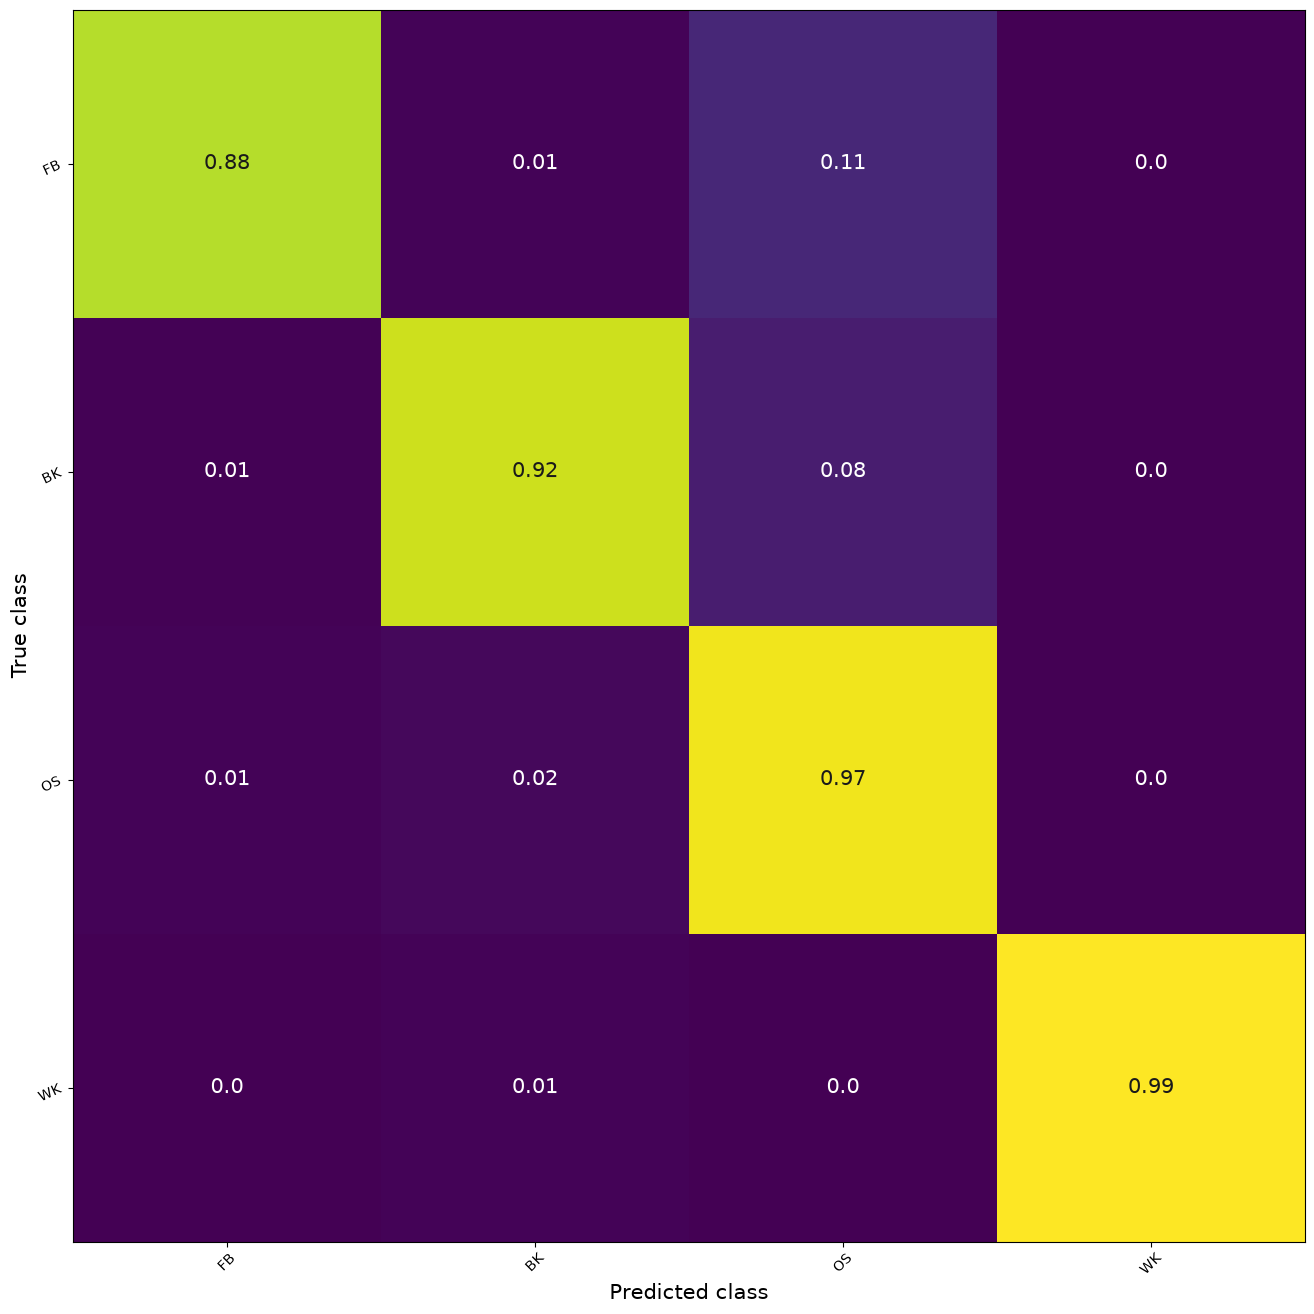

In [55]:
plt.close()
fig, ax = plt.subplots(figsize=(16, 16))

#plt.xticks(ticks=ax.get_xticks(), labels = unique_pitches)
#plt.yticks(ticks=ax.get_yticks(), labels = unique_pitches)
#plt.savefig('MLBChallenge_2011PitchPredictionCondensedAllInput_confusionmatrix_nums.png')
conf_matrix_metric.plot(ax=ax, labels=unique_pitches)
plt.show()

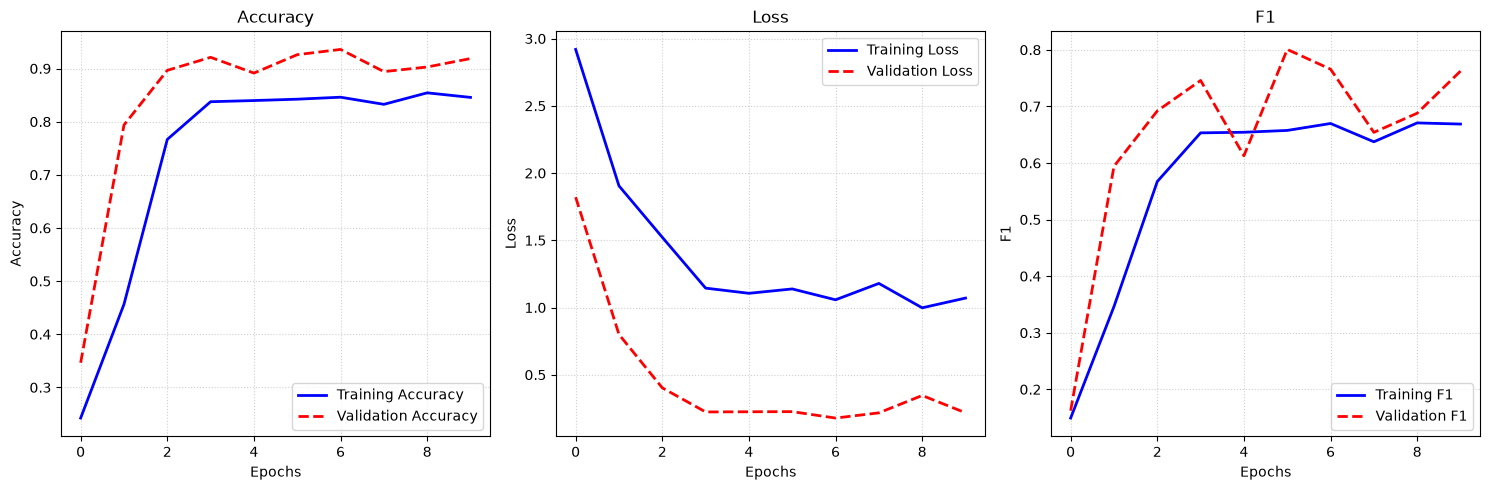

In [48]:
#this chunk is for making the figures. I've done a couple that I've attached. 

#training_accuracy_list.cpu()
plt.close()

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))


ax1.plot(training_accuracy_list, label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(validation_accuracy_list, label='Validation Accuracy', color='red', linestyle='--', linewidth=2)
ax1.set_title('Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(training_loss_list, label='Training Loss', color='blue', linewidth=2)
ax2.plot(validation_loss_list, label='Validation Loss', color='red', linestyle='--', linewidth=2)
ax2.set_title('Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

ax3.plot(torch.stack(training_f1_list).cpu(), label='Training F1', color='blue', linewidth=2)
ax3.plot(torch.stack(validation_f1_list).cpu(), label='Validation F1', color='red', linestyle='--', linewidth=2)
ax3.set_title('F1')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('F1')
ax3.legend()
ax3.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
#plt.savefig('MLBChallenge_2011PitchPredictionCondensedAllInput_Acc_loss_f1.png')
plt.show()


In [ ]:
#### THIS IS FOR CROSS FOLD VALIDATION

num_folds = 5
fold_results = []
fold_accuracy = []
fold_training_accuracy = []
fold_training_loss = []
NUM_EPOCHS = 5



kf = KFold(n_splits=num_folds, shuffle=True,random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset)):

    print(f"\n--- Training Fold {fold + 1}/{num_folds} ---")
    # 1. Device Setup (Utilize GPU if available for significantly faster training)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Number of GPUs:", torch.cuda.device_count())
    print(f"Training on device: {device}")


    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx) 

    

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


    
    
    

    BATCH_SIZE=32

    train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn = collate_at_bats_fn,
                          drop_last=True)



# Validation DataLoader (Shuffle=False to keep validation tracking consistent)
    val_loader = DataLoader(
        dataset=val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_at_bats_fn
    )



    # 4. Core Training Loop
    for epoch in range(NUM_EPOCHS):
        model.train() # Set model to training mode
        
        running_train_loss = 0.0
        total_train_pitches = 0
        
        correct_predictions=0
        
        for batch_idx, batch in enumerate(train_loader):
            # Move all tensors in the batch to your target device (CPU/GPU)
            #p_id, b_id, p_h, b_h, p_ab, game_states, prev_p, prev_v, targets = [t.to(device) for t in batch]
            p_id, b_id, game_states, prev_p, targets = [t.to(device) for t in batch]
            
            # Clear out older gradients from the previous step
            optimizer.zero_grad()
            
            # Forward pass through the network -> Shape: [Batch, Seq_Len, Classes]
            logits = model(p_id, b_id, game_states, prev_p)
            
            # Reshape for PyTorch CrossEntropy compatibility: [Batch, Seq_Len, Classes] -> [Batch, Classes, Seq_Len]
            logits_transposed = logits.transpose(1, 2)
            
            # Calculate raw matrix loss -> Shape: [Batch, Seq_Len]
            raw_loss = criterion(logits_transposed, targets)
            
            # Generate masking mechanism: Where pitcher IDs are greater than 0, real data exists
            mask = (p_id > 0).float()
            
            # Wring out the padding loss components and average over valid pitches only
            masked_loss = (raw_loss * mask).sum() / mask.sum()
            
            # Backward pass (Calculate gradients)
            masked_loss.backward()
            
            # Gradient clipping prevents explosive gradients, stabilizing the LSTM
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # Update weights
            optimizer.step()
            
            # Track training progress statistics
            running_train_loss += (raw_loss * mask).sum().item()
            total_train_pitches += mask.sum().item()

            predictions = torch.argmax(logits, dim=2) # Get the highest-probability class index
            correct_predictions += ((predictions == targets) * mask).sum().item()
            
            if batch_idx % 100 == 0:
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Batch {batch_idx}/{len(train_loader)} | Batch Loss: {masked_loss.item():.4f}")


    
            
        # Calculate total average loss for the training epoch
        fold_training_accuracy.append((correct_predictions / total_train_pitches) * 100)
        fold_training_loss.append(running_train_loss / total_train_pitches)
        
        # 5. Validation Phase (Run at the end of every epoch)
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    total_val_pitches = 0
    correct_predictions=0

    
    # Turn off gradient calculations to save VRAM and execution speed
    with torch.no_grad():
        for batch in val_loader: # Assuming you initialized a val_loader alongside train_loader
            p_id, b_id, game_states, prev_p, targets = [t.to(device) for t in batch]
            
            logits = model(p_id, b_id, game_states, prev_p)
            logits_transposed = logits.transpose(1, 2)
            
            raw_loss = criterion(logits_transposed, targets)
            mask = (p_id > 0).float()
            
            running_val_loss += (raw_loss * mask).sum().item()
            total_val_pitches += mask.sum().item()
            
            # Calculate validation accuracy metrics
            predictions = torch.argmax(logits, dim=2) # Get the highest-probability class index
            
            

            correct_predictions += ((predictions == targets) * mask).sum().item()

    fold_avg_loss = sum(fold_training_loss)/num_folds
    train_best_acc = max(fold_training_accuracy)

    fold_val_loss = running_val_loss / total_val_pitches
    fold_val_acc = (correct_predictions / total_val_pitches) * 100

    
    
    #this will output the fold information for training and validation. Accuracy will output the best accuracy of the fold
    print(f"\n======== Fold {fold+1} SUMMARY ========")
    print(f"Average train Loss: {fold_avg_loss:.4f}")
    print(f"Best train Acc: {train_best_acc:.4f}")
    print(f"Val Loss:   {fold_val_loss:.4f}")
    print(f"Val Acc:    {fold_val_acc:.2f}%\n====================================")
    
    fold_accuracy.append(fold_val_acc)

print(f"\Average accuracy across all folds: {(sum(fold_accuracy)/len(fold_accuracy))}")



In [49]:

#confusion matrix and some other stats 
y_pred = []
y_true = []
        
        # Turn off gradient calculations to save VRAM and execution speed
with torch.no_grad():
    for batch in val_loader: # Assuming you initialized a val_loader alongside train_loader
        #print(batch)
        p_id, b_id, game_states, prev_p, targets = [t.to(device) for t in batch]
        
        #print("Targets:",targets)

        logits = model(p_id, b_id, game_states, prev_p)
        #logits_transposed = logits.transpose(1, 2)
                
        #raw_loss = criterion(logits_transposed, targets)
        #mask = (p_id > 0).float()
                
        #running_val_loss += (raw_loss * mask).sum().item()
        #total_val_pitches += mask.sum().item()

        #print(logits.shape)
        #probabilities = torch.nn.functional.softmax(logits, dim=-1)       
                # Calculate validation accuracy metrics
        preds = torch.argmax(logits, dim=-1).data.cpu().numpy() # Get the highest-probability class index
        #preds = (preds >= THRESHOLD).int()
        
        #print(predictions)
        #pred_output = torch.max(torch.exp(preds), 1)[1].data.cpu().numpy()
        #print(targets.shape)
        #target_labels = torch.argmax(targets, dim=-1).data.cpu().numpy()
        target_labels = torch.flatten(targets).data.cpu().numpy()
        #pred_output = preds.cpu().numpy()
        #print(len(targets))
        #print(pred_output) 
        
        #print(preds)
        #print(target_labels)
        #add the new predictions and labels from this batch to the prediction and true
        y_pred.extend(preds)
        y_true.extend(target_labels)

       
#y_true = torch.stack(y_true).cpu().numpy()
#condense the predictions down
#y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
#print(y_true)
#print("Y_True:", y_true)

y_pred = [x.item() for x in y_pred]
y_pred = np.array(y_pred).tolist()

#y_true = [x.item() for x in y_true] 
y_true = [int(x) for x in y_true]
#y_true = [item for sublist in y_true for item in sublist]
#y_true = y_true.tolist()

#print("y_pred", y_pred)
#print("y_true:", y_true)



#pitch_dict = {0:'FF', 1:'FT', 2:'SL', 3:'CH', 4:'FC', 5:'CU', 6:'SI', 7:'KC', 8:'IN', 9:'KN', 10:'FS', 11:'FA', 12:'PO',
# 13:'FO'}
#this is the 100th time I've gotten the unique pitches. But I want to make sure it works in this chunk
#unique_pitches = pitchdata["pitch_type"].unique()
#print(len(unique_pitches))
#convert it back to it's indexed pitch
pitch_dict = dict(zip(range(len(unique_pitches)), unique_pitches))
print(pitch_dict)

#convert from index to pitch type
#y_pred = y_pred.map(pitch_dict)
y_pred = [pitch_dict[item] for item in y_pred]
y_true = [pitch_dict[item] for item in y_true]

#print(y_pred)
#print(y_true)

#print(len(y_pred))
#print(len(y_true))




#print(classes)
#get confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)

#calculate the appearance of each pitch type for the true predictions
appearance = Counter(y_true)
classes = list(pitch_dict.values())
classes.sort()
#classes = np.unique(y_pred+y_true)  #prediction might include a class not found in ground truth. Add lists together here and find unique
print(f'Breakdown of pitches: {appearance}')
print(f'Classes: {classes}')

#print(cf_matrix)


#confusion matrix
df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:,None], index=[i for i in classes], columns=[i for i in classes])

plt.close()
plt.figure(figsize = (12, 7))
sn.heatmap(df_cm, annot=True)
plt.show()
#plt.savefig('MLBChallenge_2011PitchPrediction_condenseClassesALLINPUT_CM.png')

{0: 'FB', 1: 'SL', 2: 'CH', 3: 'CU', 4: 'KC', 5: 'IN', 6: 'KN', 7: 'FS', 8: 'PO', 9: 'FO', 10: 'EP'}
Breakdown of pitches: Counter({'FB': 34091, 'SL': 2981, 'CH': 2226, 'CU': 1634, 'FS': 268, 'KC': 247, 'KN': 89, 'IN': 77, 'PO': 21, 'FO': 16})
Classes: ['CH', 'CU', 'EP', 'FB', 'FO', 'FS', 'IN', 'KC', 'KN', 'PO', 'SL']


ValueError: Shape of passed values is (10, 10), indices imply (11, 11)

c:\Users\zkile\Documents\Coding\ML_Practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zkile\Documents\Coding\ML_Practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zkile\Documents\Coding\ML_Practice\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

              precision    recall  f1-score   support

          CH       0.80      0.91      0.85      2134
          CU       0.96      0.98      0.97      1571
          EP       0.00      0.00      0.00         2
          FA       1.00      0.83      0.91         6
          FC       0.40      0.92      0.56      1260
          FF       0.99      0.79      0.88     28117
          FO       0.86      0.92      0.89        13
          FS       0.67      0.97      0.80       281
          FT       0.58      0.89      0.70      2146
          IN       0.67      0.99      0.80        88
          KC       0.92      0.99      0.95       263
          KN       0.83      1.00      0.91        79
          PO       0.81      0.96      0.88        23
          SI       0.51      0.93      0.66      2609
          SL       0.80      0.82      0.81      2981

    accuracy                           0.83     41573
   macro avg       0.72      0.86      0.77     41573
weighted avg       0.89   

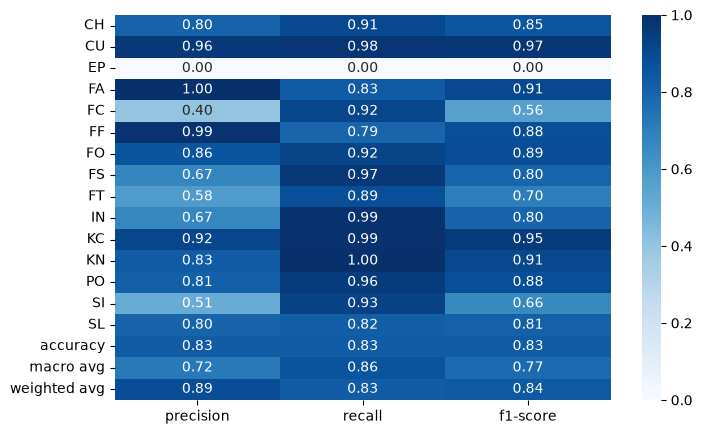

In [36]:
#plt.close()
#plt.figure(figsize = (12, 7))
#sn.heatmap(df_cm, annot=True)
#plt.show()

#precision = precision_score(y_true, y_pred)
print(classification_report(y_true, y_pred))
class_report_df = pd.DataFrame(classification_report(y_true, y_pred,output_dict=True))
class_report_vals = class_report_df.iloc[:-1,:].T
class_report_support = class_report_df.iloc[:, -1]

plt.figure(figsize=(8,5))
sn.heatmap(class_report_vals, annot=True, cmap="Blues", fmt=".2f", vmin=0.0, vmax=1.0)
plt.show()
#plt.savefig('MLBChallenge_2011PitchPrediction_condenseClassesALLINPUT_classificationreport.png')

In [ ]:
print(len(pitchdata["pitch_type"].unique()))
pitch_dict = dict(zip(range(len(pitchdata["pitch_type"].unique())), pitchdata["pitch_type"].unique()))
print(pitch_dict)

In [ ]:
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch visible GPU count: {torch.cuda.device_count()}")
print(f"PyTorch current device index: {torch.cuda.current_device()}")
print(f"PyTorch device name: {torch.cuda.get_device_name(0)}")
print(f"CUDA_VISIBLE_DEVICES env var: {os.environ.get('CUDA_VISIBLE_DEVICES')}")